In [31]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR

from tqdm.notebook import tqdm
import numpy as np
np.set_printoptions(suppress=True)

import matplotlib.pyplot as plt

In [2]:
from simulators import NestedModelFamily, ContextManager
from simulators.benchmarks import DDM
from adapters import Adapter

# Transformer

In [3]:
class MAB(nn.Module):
    """
    Multihead Attention Block using torch.nn.MultiheadAttention.

    Args:
        dim_Q:  feature dim of Q input  (B, T_q, dim_Q)
        dim_K:  feature dim of K input  (B, T_k, dim_K)
        dim_V:  internal/embed dim for attention and output
        num_heads: number of attention heads
        ln: whether to use LayerNorm before/after the FFN residual
    """
    def __init__(self, query_dim: int, key_dim: int = None, num_heads: int = 4, ln: bool = False, dropout: float = 0.0):
        super().__init__()

        if key_dim is None:
            key_dim = query_dim

        # Built-in MHA; batch_first=True to accept (B, T, C)
        self.attn = nn.MultiheadAttention(
            embed_dim=query_dim,
            kdim=key_dim,
            vdim=key_dim,
            num_heads=num_heads,
            dropout=dropout,
            batch_first=True,
        )

        self.ln0 = nn.LayerNorm(query_dim) if ln else None
        self.ln1 = nn.LayerNorm(query_dim) if ln else None

        self.fc_o = nn.Linear(query_dim, query_dim)

    def forward(self,
        query: torch.Tensor,
        key: torch.Tensor,
        attn_mask: torch.Tensor = None,
        key_padding_mask: torch.Tensor = None
    ) -> torch.Tensor:
        """
        Q: (B, T_q, dim_Q)
        K: (B, T_k, dim_K) — used for both keys and values
        attn_mask: optional (T_q, T_k) or (B*num_heads, T_q, T_k)
        key_padding_mask: optional (B, T_k), True for PAD positions
        """

        attn_out, _ = self.attn(
            query=query,
            key=key,
            value=key,
            attn_mask=attn_mask,
            key_padding_mask=key_padding_mask,
            need_weights=False,
        )

        # 3) First residual (q + attention), optional LayerNorm
        out = query + attn_out
        if self.ln0 is not None:
            out = self.ln0(out)

        # 4) Simple FFN + residual (match original: ReLU then linear)
        out = out + F.gelu(self.fc_o(out))
        if self.ln1 is not None:
            out = self.ln1(out)

        return out


class SAB(nn.Module):
    def __init__(self, input_dim: int, num_heads: int = 4, ln: bool = False, dropout: float = 0.0):
        super().__init__()
        self.mab = MAB(query_dim=input_dim, num_heads=num_heads, ln=ln, dropout=dropout)

    def forward(self, X, attn_mask=None, key_padding_mask=None):
        return self.mab(X, X, attn_mask=attn_mask, key_padding_mask=key_padding_mask)

class PMA(nn.Module):
    def __init__(
        self,
        input_dim: int,
        seed_dim: int,
        num_heads: int = 4,
        num_seeds: int = 1,
        ln: bool = False,
        dropout: float = 0.0
):
        super().__init__()
        self.S = nn.Parameter(torch.Tensor(1, num_seeds, seed_dim))
        nn.init.xavier_uniform_(self.S)
        self.mab = MAB(query_dim=seed_dim, key_dim=input_dim, num_heads=num_heads, ln=ln, dropout=dropout)

    def forward(self, X):
        return self.mab(self.S.repeat(X.size(0), 1, 1), X)

In [4]:
class Encoder(nn.Module):

    def __init__(
        self,
        input_dim: int,
        embed_dim: int = 64,
        seed_dim: int = 128,
        num_layers: int = 3,
        num_seeds: int = 1,
        num_heads: int = 4,
        ln: bool = False,
        dropout: float = 0.0,
        layer_dropout: float = 0.0,
    ):
        super().__init__()
        assert num_layers >= 1, "num_layers must be >= 1"

        self.input_embedding = nn.Linear(input_dim, embed_dim)

        self.layers = nn.ModuleList(
            [SAB(input_dim=embed_dim, num_heads=num_heads, ln=ln, dropout=dropout)
             for _ in range(num_layers)]
        )
        self.post_dropout = nn.Dropout(layer_dropout) if layer_dropout > 0 else nn.Identity()

        self.pma = PMA(
            input_dim=embed_dim,
            seed_dim=seed_dim,
            num_seeds=num_seeds,
            num_heads=num_heads,
            ln=ln,
            dropout=dropout
        )

    def forward(self, x, attn_mask=None, key_padding_mask=None):
        """
        X: (B, T, C)
        attn_mask: optional (T, T) or (B*num_heads, T, T)
        key_padding_mask: optional (B, T) with True for PAD tokens
        """

        out = self.input_embedding(x)

        for sab in self.layers:
            out = sab(out, attn_mask=attn_mask, key_padding_mask=key_padding_mask)
            out = self.post_dropout(out)

        pooled = self.pma(out)
        return pooled

In [5]:
class Decoder(nn.Module):

    def __init__(
        self,
        input_dim: int,
        proj_dim: int = 64,
        num_layers: int = 3,
        num_heads: int = 4,
        ln: bool = False,
        dropout: float = 0.0,
        layer_dropout: float = 0.0,
    ):
        super().__init__()
        assert num_layers >= 1, "num_layers must be >= 1"

        self.input_proj = nn.Linear(input_dim, proj_dim)

        self.layers = nn.ModuleList(
            [SAB(input_dim=proj_dim, num_heads=num_heads, ln=ln, dropout=dropout)
             for _ in range(num_layers)]
        )
        self.post_dropout = nn.Dropout(layer_dropout) if layer_dropout > 0 else nn.Identity()

        self.output_proj = nn.Linear(proj_dim, 2)


    def forward(self, x, attn_mask=None, key_padding_mask=None):
        """
        X: (B, T, C)
        attn_mask: optional (T, T) or (B*num_heads, T, T)
        key_padding_mask: optional (B, T) with True for PAD tokens
        """

        out = self.input_proj(x)

        for sab in self.layers:
            out = sab(out, attn_mask=attn_mask, key_padding_mask=key_padding_mask)
            out = self.post_dropout(out)

        mu, log_var = self.output_proj(out).chunk(2, dim=-1)
        return mu, log_var

In [53]:
class BayesGPTv0(nn.Module):

    def __init__(
        self,
        encoder_input_dim: int,
        proj_dim: int = 64,
        encoder_num_layers: int = 3,
        decoder_num_layers: int = 3,
        encoder_num_heads: int = 4,
        decoder_num_heads: int = 4,
        seed_dim: int = 128,
        ln: bool = True,
        dropout: float = 0.0,
        layer_dropout: float = 0.0,
    ):
        super().__init__()

        self.encoder = Encoder(
            input_dim=encoder_input_dim,
            num_layers=encoder_num_layers,
            seed_dim=seed_dim,
            num_heads=encoder_num_heads,
            ln=ln,
            dropout=dropout,
            layer_dropout=layer_dropout,
        )

        self.decoder = Decoder(
            input_dim=seed_dim+2,
            proj_dim=proj_dim,
            num_layers=decoder_num_layers,
            num_heads=decoder_num_heads,
            ln=ln,
            dropout=dropout,
            layer_dropout=layer_dropout,
        )

    def forward(self, input_data, param_indices, regressor_indices, attn_mask=None, key_padding_mask=None):

        data_rep = self.encoder(input_data)
        data_rep = data_rep.repeat(1, regressor_indices.size(1), 1)

        data_rep_pos = torch.cat([data_rep, param_indices, regressor_indices], dim=-1)

        decoded_mu, decoded_logvar = self.decoder(data_rep_pos, attn_mask=attn_mask, key_padding_mask=key_padding_mask)

        return decoded_mu, decoded_logvar

## Loss functionm

In [7]:
def loss(true_params, mu, logvar, param_masks) -> torch.Tensor:
    """
    Heteroskedastic Gaussian NLL with masking.
    """

    mu = mu.squeeze(dim=-1)
    logvar = logvar.squeeze(dim=-1)

    inv_var = torch.exp(-logvar)
    nll = 0.5 * ((true_params - mu)**2 * inv_var + logvar)

    nll_masked = nll * param_masks
    denom = param_masks.sum(dim=-1)
    return torch.mean(nll_masked.sum(dim=-1) / denom)

# Simulator using `NestedModelFamily`

We start with DDM

In [8]:
ddm_intrinsics = ["v", "a", "tau", "s_v", "s_tau", "decay"]

In [9]:
# TODO: (maybe) automatically detect which parameters have both intercepts and slopes as priors
ddm_priors = {
    "v":     {"intercept": lambda: np.random.gamma(3.0, 0.8),
              "slope":     lambda: np.random.normal(0.0, 3.0)},
    "a":     {"intercept": lambda: np.random.gamma(10.0, 0.3),
              "slope":     lambda: np.random.normal(0.0, 1.0)},
    "tau":   {"intercept": lambda: np.random.gamma(3.0, 0.2),
              "slope":     lambda: 0.0},
    "s_v":   {"intercept": lambda: np.random.gamma(1.0, 0.2),
              "slope":     lambda: 0.0},
    "s_tau": {"intercept": lambda: np.random.uniform(0.0, 0.4),
              "slope":     lambda: 0.0},
    "decay": {"intercept": lambda: np.random.gamma(1.0, 0.4),
              "slope":     lambda: 0.0},
}

In [10]:
# TODO: Automatically generate ContextManager if none provided
context_manager = ContextManager()

In [13]:
model_family = NestedModelFamily(
    name="DDM",
    model=DDM(),
    context_manager=context_manager,
    prior_fun=ddm_priors,
    intrinsic_params=ddm_intrinsics,
)

In [14]:
samples = model_family.batch_sample(
    batch_size=8,
    mask_randomizer_kwargs=dict(
        free_intrinsics={"v", "a", "tau", "s_v", "decay"},
        fixed_intrinsics={"s_tau"}
    ),
    num_obs=200,
    flatten_param_outputs=True
)

In [15]:
adapter = Adapter()

In [16]:
def to_device(batch, device):
    out = {}
    for k, v in batch.items():
        out[k] = v.to(device)
    return out

## BayesGPT

In [54]:
bayesgpt = BayesGPTv0(encoder_input_dim=32)

In [ ]:
grad_clip_norm = 5.
batch_size = 32
epochs = 100
steps_per_epoch = 1000
learning_rate = 1e-4

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

bayesgpt.to(device)
bayesgpt.train()

optimizer = AdamW(bayesgpt.parameters(), lr=learning_rate)
scheduler = CosineAnnealingLR(optimizer, T_max=epochs)

for ep in range(epochs):
    pbar = tqdm(total=steps_per_epoch, desc=f"Epoch {ep+1}/{epochs}", miniters=100)

    for step in range(steps_per_epoch):

        samples = model_family.batch_sample(
            batch_size=batch_size,
            mask_randomizer_kwargs=dict(
                free_intrinsics={"v", "a", "tau", "s_v", "decay"},
                fixed_intrinsics={"s_tau"}
            ),
            num_obs=200,
            flatten_param_outputs=True
        )

        adapted = adapter.adapt(samples, intrinsic_params=ddm_intrinsics)                   # user-provided
        adapted = to_device(adapted, device)

        optimizer.zero_grad()

        mu, logvar = bayesgpt(adapted["input_data"], adapted["param_indices"], adapted["regressor_indices"])


        L = loss(adapted["param_matrices"], mu, logvar, adapted["param_masks"])
        L.backward()

        if grad_clip_norm is not None:
            torch.nn.utils.clip_grad_norm_(bayesgpt.parameters(), grad_clip_norm)

        optimizer.step()

        loss_val = L.detach().item()
        current_lr = scheduler.get_last_lr()[0]

        pbar.set_postfix(loss=f"{loss_val:.4f}", lr=f"{current_lr:.2e}")
        pbar.update(1)

    scheduler.step()
    pbar.close()

Epoch 1/100:   0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 2/100:   0%|          | 0/1000 [00:00<?, ?it/s]

In [45]:
test_set = model_family.batch_sample(
        batch_size=100,
        mask_randomizer_kwargs=dict(
            free_intrinsics={"v", "a", "tau", "s_v", "decay"},
            fixed_intrinsics={"s_tau"}
        ),
        num_obs=200,
        flatten_param_outputs=True
)

adapted = adapter.adapt(samples, intrinsic_params=ddm_intrinsics)                   # user-provided
adapted = to_device(adapted, device)

In [46]:
bayesgpt.eval()

mu, logvar = bayesgpt(adapted["input_data"], adapted["param_indices"], adapted["regressor_indices"])

In [49]:
true = adapted["param_matrices"][:, 2].detach().cpu().numpy()
pred = mu[:, 2].detach().cpu().numpy()

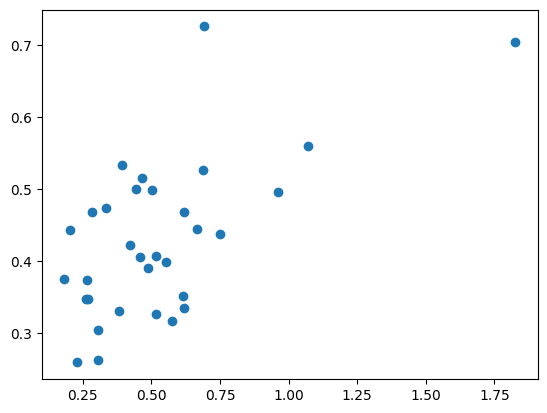

In [50]:
plt.scatter(true, pred)